# 02 - IEEE-CIS Predictive Model Benchmarks

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

KAGGLE = Path("/kaggle").exists()
REPO_URL = "https://github.com/Tommyhuy1705/Explainable_NeuroSymbolic_Fraud_Detection.git"
KAGGLE_PROJECT_DIR = Path("/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection")

if KAGGLE:
    os.environ["THESIS_QUICK_RUN"] = "0"
    os.environ["THESIS_SYNTHETIC_FALLBACK"] = "0"
    if not KAGGLE_PROJECT_DIR.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(KAGGLE_PROJECT_DIR)],
            check=True,
        )

def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if base.exists():
            matches = [path for path in base.glob("**/configs") if path.is_dir()]
            if matches:
                return matches[0].parent
    raise FileNotFoundError("Project root with src/ and configs/ was not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

QUICK_RUN = os.getenv("THESIS_QUICK_RUN", "0") == "1"
ALLOW_SYNTHETIC_FALLBACK = os.getenv("THESIS_SYNTHETIC_FALLBACK", "0") == "1"
OUTPUT_BASE = Path("/kaggle/working/thesis_outputs") if KAGGLE else PROJECT_ROOT / "results/runs/notebooks"
INPUT_ROOTS = [OUTPUT_BASE, PROJECT_ROOT / "results/runs/notebooks"]
if Path("/kaggle/input").exists():
    INPUT_ROOTS.append(Path("/kaggle/input"))

try:
    GIT_COMMIT = subprocess.check_output(
        ["git", "-C", str(PROJECT_ROOT), "rev-parse", "HEAD"], text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_COMMIT = None

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)
print({
    "project_root": str(PROJECT_ROOT),
    "git_commit": GIT_COMMIT,
    "quick_run": QUICK_RUN,
    "synthetic_fallback": ALLOW_SYNTHETIC_FALLBACK,
    "kaggle": KAGGLE,
})

Cloning into '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection'...


{'project_root': '/kaggle/working/Explainable_NeuroSymbolic_Fraud_Detection', 'git_commit': 'f30635ece025de6643fa50263565b4b1a2ccda24', 'quick_run': False, 'synthetic_fallback': False, 'kaggle': True}


## Thiết lập

PR-AUC là metric xếp hạng chính. Mỗi full run dùng ba seeds. Calibration được fit trên nửa đầu
validation, chọn trên nửa sau validation; decision threshold cũng chỉ chọn trên nửa sau validation.
Reference predictor được chọn bằng mean validation raw PR-AUC, không dùng test.

In [2]:
from src.experiment import run_repeated_predictive_benchmarks

output_dir = OUTPUT_BASE / "02_ieee_cis_model_benchmarks"
result = run_repeated_predictive_benchmarks(
    PROJECT_ROOT / "configs/ieee_cis.yaml",
    output_dir=output_dir,
    model_names=("mlp", "tabular_resnet", "tree"),
    quick_run=QUICK_RUN,
    synthetic_fallback=ALLOW_SYNTHETIC_FALLBACK,
)
summary = result["summary"]
print({
    "data_sources": result["data_sources"],
    "seeds": result["seeds"],
    "reference_model_key": result["reference_model_key"],
    "reference_seed": result["reference_seed"],
    "frozen_manifest": str(result["frozen_manifest_path"]),
})
display(summary.round(4))

{'data_sources': ['real'], 'seeds': [42, 123, 2026], 'reference_model_key': 'tree', 'reference_seed': 42, 'frozen_manifest': '/kaggle/working/thesis_outputs/02_ieee_cis_model_benchmarks/frozen_reference_manifest.json'}


,model,model_key,split,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,fbeta_mean,fbeta_std,brier_mean,brier_std,ece_mean,ece_std,nll_mean,nll_std,threshold_mean,threshold_std,positive_rate_mean,positive_rate_std,raw_pr_auc_mean,raw_pr_auc_std,raw_roc_auc_mean,raw_roc_auc_std,n_seeds
0,MLP,mlp,test,0.3465,0.0114,0.8089,0.0053,0.2561,0.0460,0.5299,0.0357,0.3422,0.0325,0.4327,0.0057,0.0268,0.0003,0.0046,0.0019,0.1176,0.0036,0.0808,0.0081,0.0741,0.0171,0.3606,0.0162,0.8095,0.0049,3
1,MLP,mlp,validation,0.3993,0.0095,0.8310,0.0009,0.2558,0.0249,0.5679,0.0171,0.3520,0.0210,0.4554,0.0081,0.0250,0.0003,0.0020,0.0004,0.1080,0.0006,0.0808,0.0081,0.0769,0.0103,0.4119,0.0076,0.8301,0.0010,3
2,TabularResNet,tabular_resnet,test,0.3213,0.0183,0.7941,0.0054,0.2250,0.0312,0.5141,0.0104,0.3119,0.0274,0.4075,0.0144,0.0274,0.0006,0.0026,0.0008,0.1181,0.0023,0.0818,0.0133,0.0806,0.0119,0.3364,0.0181,0.7951,0.0057,3
3,TabularResNet,tabular_resnet,validation,0.3941,0.0018,0.8212,0.0020,0.2654,0.0192,0.5302,0.0214,0.3531,0.0129,0.4412,0.0023,0.0251,0.0001,0.0016,0.0002,0.1084,0.0007,0.0818,0.0133,0.0690,0.0080,0.4064,0.0031,0.8199,0.0026,3
4,xgboost,tree,test,0.4407,0.0029,0.8667,0.0025,0.2545,0.0046,0.5819,0.0098,0.3541,0.0035,0.4628,0.0036,0.0244,0.0001,0.0076,0.0006,0.1058,0.0012,0.0849,0.0049,0.0796,0.0026,0.4557,0.0039,0.8672,0.0023,3
5,xgboost,tree,validation,0.5178,0.0044,0.9038,0.0003,0.2975,0.0066,0.6464,0.0091,0.4074,0.0048,0.5235,0.0028,0.0218,0.0002,0.0024,0.0003,0.0904,0.0004,0.0849,0.0049,0.0747,0.0026,0.5316,0.0042,0.9032,0.0004,3


## Data and calibration

In [3]:
display(result["data_summary"])
selected_calibration = result["calibration_comparison"].query("selected").copy()
display(selected_calibration.round(5))
display(result["predictive_bootstrap"].round(5))

,split,rows,time_min,time_max,time_group_count,time_groups,overlap_groups,group_disjoint,fraud_rate
0,train,413378,86400,10437996,400309,[],[],True,0.035169
1,validation,88581,10438003,13151840,86545,[],[],True,0.034341
2,test,88581,13151880,15811131,86495,[],[],True,0.034804


,seed,model,model_key,method,brier,ece,nll,fit_rows,selection_rows,selected
2,42,MLP,mlp,isotonic,0.02594,0.00458,0.11391,44290.0,44291.0,True
5,42,TabularResNet,tabular_resnet,isotonic,0.02668,0.00339,0.11573,44290.0,44291.0,True
8,42,xgboost,tree,isotonic,0.02387,0.00533,0.09933,44290.0,44291.0,True
11,123,MLP,mlp,isotonic,0.02649,0.00312,0.11459,44290.0,44291.0,True
14,123,TabularResNet,tabular_resnet,isotonic,0.02643,0.00284,0.11382,44290.0,44291.0,True
17,123,xgboost,tree,isotonic,0.02338,0.00422,0.09793,44290.0,44291.0,True
20,2026,MLP,mlp,isotonic,0.02632,0.00425,0.11568,44290.0,44291.0,True
23,2026,TabularResNet,tabular_resnet,isotonic,0.02650,0.00335,0.11366,44290.0,44291.0,True
26,2026,xgboost,tree,isotonic,0.02334,0.00488,0.09729,44290.0,44291.0,True


,reference_model_key,comparator_model_key,observed_difference,bootstrap_mean_difference,ci_low,ci_high,probability_a_better,bootstrap_iterations,bootstrap_rows
0,tree,mlp,0.08680,0.08647,0.07444,0.10080,1.0,300.0,88581.0
1,tree,tabular_resnet,0.13689,0.13716,0.12071,0.15465,1.0,300.0,88581.0


## Results

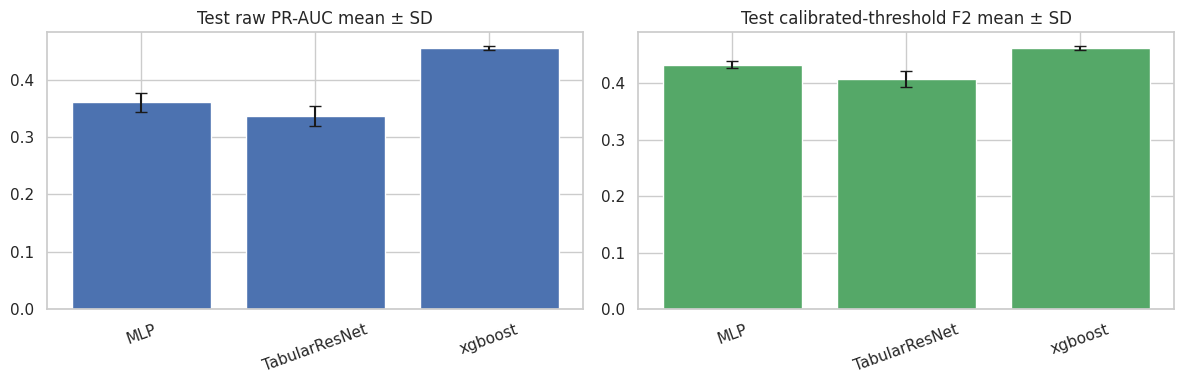

In [4]:
test_metrics = summary.query("split == 'test'").copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(test_metrics["model"], test_metrics["raw_pr_auc_mean"],
            yerr=test_metrics["raw_pr_auc_std"].fillna(0), color="#4C72B0", capsize=4)
axes[0].set_title("Test raw PR-AUC mean ± SD")
axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(test_metrics["model"], test_metrics["fbeta_mean"],
            yerr=test_metrics["fbeta_std"].fillna(0), color="#55A868", capsize=4)
axes[1].set_title("Test calibrated-threshold F2 mean ± SD")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(output_dir / "predictive_model_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

In [5]:
history_rows = []
for seed, model_histories in result["histories"].items():
    for model_name, history in model_histories.items():
        history_frame = pd.DataFrame(history)
        best_index = history_frame["validation_pr_auc"].idxmax()
        history_rows.append({
            "seed": seed, "model": model_name, "epochs_run": len(history_frame),
            "best_epoch": int(history_frame.loc[best_index, "epoch"]),
            "best_validation_pr_auc": history_frame.loc[best_index, "validation_pr_auc"],
        })
display(pd.DataFrame(history_rows).round(5))

,seed,model,epochs_run,best_epoch,best_validation_pr_auc
0,42,mlp,100,89,0.41764
1,42,tabular_resnet,92,72,0.40751
2,123,mlp,75,60,0.40325
3,123,tabular_resnet,88,68,0.40889
4,2026,mlp,100,86,0.41473
5,2026,tabular_resnet,64,44,0.40288


## Takeaways

In [6]:
selected_key = result["reference_model_key"]
validation_best = summary.query("split == 'validation' and model_key == @selected_key").iloc[0]
test_reference = summary.query("split == 'test' and model_key == @selected_key").iloc[0]
display(Markdown(
    f"- Reference model selected on validation: **{validation_best['model']}**.\n"
    f"- Mean validation raw PR-AUC: **{validation_best['raw_pr_auc_mean']:.4f}**.\n"
    f"- Locked test raw PR-AUC: **{test_reference['raw_pr_auc_mean']:.4f} ± {test_reference['raw_pr_auc_std']:.4f}**.\n"
    f"- Frozen reference seed: **{result['reference_seed']}**.\n"
    "- Test metrics report the locked protocol; they are not used for model, calibration, or threshold selection."
))

- Reference model selected on validation: **xgboost**.
- Mean validation raw PR-AUC: **0.5316**.
- Locked test raw PR-AUC: **0.4557 ± 0.0039**.
- Frozen reference seed: **42**.
- Test metrics report the locked protocol; they are not used for model, calibration, or threshold selection.